In [1]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.utils import ModelInputOutputWrapper
from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "tu_berlin"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}



architecture = default_architecutre_mapping[dataset]
budget = None
repeats = 5
if dataset == "tu_berlin":
    repeats = 20
if dataset == "modelnet10":
    repeats = 10
if dataset == "coil100":
    repeats = 10



In [2]:
from utils.transforms.apply import grid_resample_border,grid_resample_reflection

In [3]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

Loaded cached TU-Berlin dataset (max_len=200, interpolation_points=2)


In [4]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

In [5]:
x=next(iter(test_loader_transformed))[0]

In [6]:
batch_size = next(iter(train_loader))[0].shape[0]


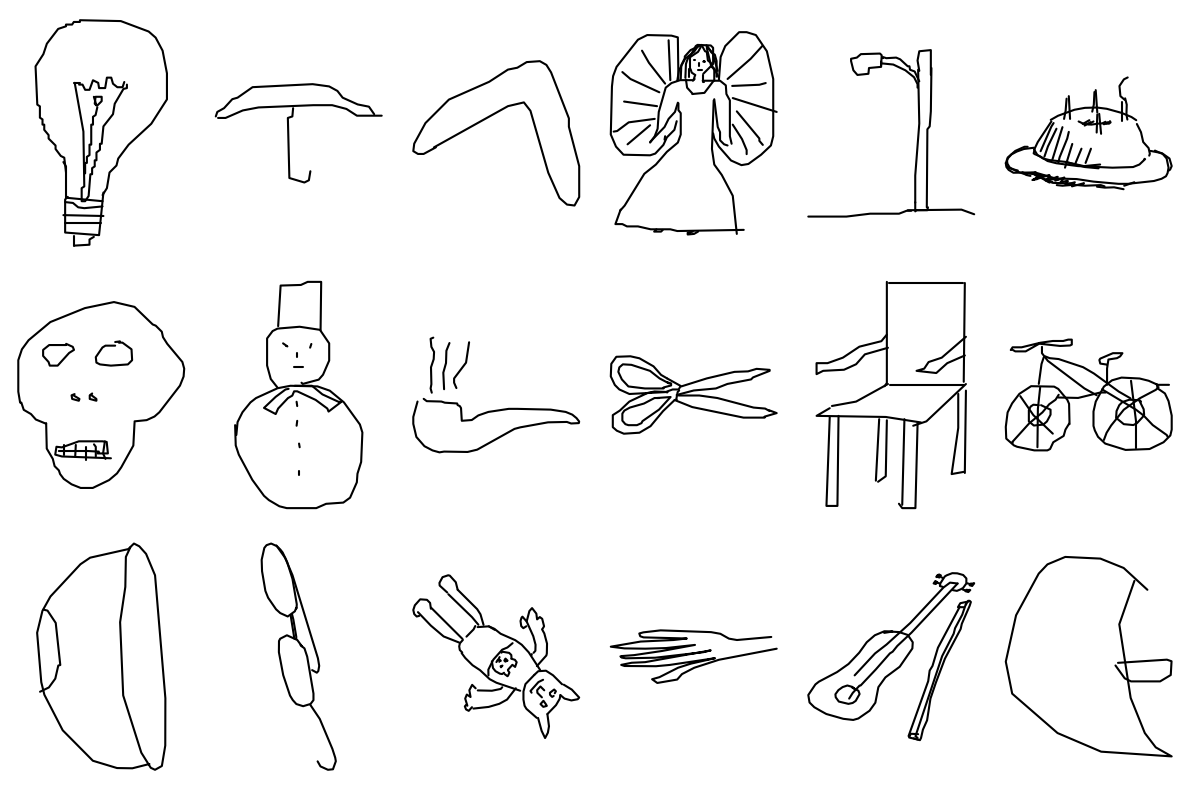

In [7]:
from utils.eval.vis import vis_dataset, plt_setup_latex

vis_dataset(train_loader,val_loader,test_loader_transformed)

In [8]:
from experiment_thesis.main import train_and_get_model,train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparison_supervised_methods")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

In [9]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm.safetensors


(BILSTMSKETCHClassifier(
   (preprocess): NormalizeToRangeBatched()
   (rnn): LSTM(3, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
   (attention): Linear(in_features=512, out_features=1, bias=False)
   (attn_dropout): Dropout(p=0.2, inplace=False)
   (augmentation): StrokeAugment()
   (classifier): Sequential(
     (0): Linear(in_features=512, out_features=512, bias=True)
     (1): GELU(approximate='none')
     (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
     (3): Dropout(p=0.5, inplace=False)
     (4): Linear(in_features=512, out_features=250, bias=True)
   )
 ),
 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\models\\tu_berlin_bi_lstm.safetensors')

In [10]:
model.eval().to(device)

BILSTMSKETCHClassifier(
  (preprocess): NormalizeToRangeBatched()
  (rnn): LSTM(3, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=False)
  (attn_dropout): Dropout(p=0.2, inplace=False)
  (augmentation): StrokeAugment()
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=250, bias=True)
  )
)

In [11]:
#chek if data is image data
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]

In [12]:
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]


from utils.replacer import replace_rotation_transforms_2vec


from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
    init_method="sobol"
).to(device)

if dataset == "modelnet10":
    transform_seq = replace_rotation_transforms_2vec(transform_seq)

In [13]:
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

layer,layer_io = get_network_layer(dataset_info, architecture, 0, num_classes=None, num_rotations=8)

In [14]:
from confidence.direct.logit_based import EnergyConfidence
from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence

logit_energy = SinglePassConfidence(model, EnergyConfidence(), index=None)
problem_energy_logits = TransformationProblem(logit_energy, transform_seq,                                              consolidate_method="consolidate_simple")
#test ot
from search.shgo import SHGO
optimizer = SHGO(initial_samples=46, local_runs=2, local_max_steps=3,local_opt_kwargs={"lr":0.1})
if dataset == "tu_berlin":
    optimizer = SHGO(initial_samples=60,local_runs=1,local_max_steps=0,local_opt_kwargs={"lr":0.1})

from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search, evaluate_confidence_and_search, \
    ITSWRAPPER


In [15]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("energy_confidence_transformed"), show_progress=True,
    repeats=1)

{'repeats': 10,
 'accuracy_mean': 0.20639999210834503,
 'accuracy_std': 0.0034058759920299053,
 'accuracy_se': 0.0010770325562899986,
 'f2_macro_mean': 0.20650723576545715,
 'f2_macro_std': 0.004040624480694532,
 'f2_macro_se': 0.0012777576528429778,
 'f2_micro_mean': 0.20639999210834503,
 'f2_micro_std': 0.0034058759920299053,
 'f2_micro_se': 0.0010770325562899986,
 'f2_weighted_mean': 0.2052268534898758,
 'f2_weighted_std': 0.003268339904025197,
 'f2_weighted_se': 0.0010335398264335746,
 'per_run': [{'accuracy': 0.21400000154972076,
   'f2_macro': 0.2168620228767395,
   'f2_micro': 0.21400000154972076,
   'f2_weighted': 0.21214571595191956,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.20250000059604645,
   'f2_macro': 0.20330160856246948,
   'f2_micro': 0.20250000059604645,
   'f2_weighted': 0.20110300183296204,
   'per_sample_errors': None,
   'per_

In [16]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [17]:
#check wether main model is deterministic
x = next(iter(test_loader_transformed))[0]
out1 = model(x.to(device))
out2 = model(x.to(device))
print(torch.allclose(out1, out2))

True


In [18]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic

def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)
namef = f"{modelname}_energy2" if not is_image_data else f"{modelname}_energy2_only_blur_aug"
energy_conf_default = train_or_load_energy_model(
    energy_model2, model_dir_path, namef, train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)

energy_conf_default.to(device).eval()



problem_energy_default = TransformationProblem(energy_conf_default, transform_seq,
                                               consolidate_method="consolidate_simple")
savepathname = savepath("learned_energy_confidence_only_blur_aug_transformed") if is_image_data else savepath("learned_energy_confidence_transformed")
res = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_default,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepathname, show_progress=True,
    repeats=repeats)


#unload values
del energy_model2
del energy_conf_default
del problem_energy_default
print(res)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy2_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 20, 'accuracy_mean': 0.2859500050544739, 'accuracy_std': 0.009199395775794983, 'accuracy_se': 0.0020570474306601996, 'f2_macro_mean': 0.27847886085510254, 'f2_macro_std': 0.009961415082216263, 'f2_macro_se': 0.0022274401275927218, 'f2_micro_mean': 0.2859500050544739, 'f2_micro_std': 0.009199395775794983, 'f2_micro_se': 0.0020570474306601996, 'f2_weighted_mean': 0.28097859025001526, 'f2_weighted_std': 0.009438939392566681, 'f2_weighted_se': 0.002110611011727967, 'per_run': [{'accuracy': 0.2919999957084656, 'f2_macro': 0.28663501143455505, 'f2_micro': 0.2919999957084656, 'f2_weighted': 0.2876991629600525, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'accuracy': 0.29850000

In [19]:
layer, layer_io = get_network_layer(dataset_info, architecture, 1, num_classes=None, num_rotations=8)

In [20]:
dual_model = ModelInputOutputWrapper(model, layer, capture_modes=layer_io,flatten=False).to(device)

In [21]:
embed,logits = dual_model(next(iter(test_loader_transformed))[0].to(device))


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EmbeddingProcessor(nn.Module):
    def __init__(self, embed_shape, embed_dim=512, conv_channels=256):
        """
        Args:
            embed_shape: shape of embeds (e.g., (B, D) or (B, C, H, W))
            embed_dim:   output feature dimension after processing
            conv_channels: number of channels in conv layers (for spatial embeds)
        """
        super().__init__()
        self.is_2d = len(embed_shape) == 2  # (B, D) = dense embeddings

        if self.is_2d:
            in_dim = embed_shape[1]
            self.network = nn.Sequential(
                nn.Linear(in_dim, embed_dim),
                nn.GELU(),
                nn.Linear(embed_dim, embed_dim),
                nn.GELU(),
                nn.Linear(embed_dim, embed_dim),
                nn.GELU(),
                nn.Linear(embed_dim, 1),
            )
        else:
            # assume shape = (B, C, H, W)
            c = embed_shape[1]
            self.conv_net = nn.Sequential(
                nn.Conv2d(c, conv_channels, kernel_size=3, padding=1),
                nn.GELU(),
                nn.Conv2d(conv_channels, conv_channels, kernel_size=3, padding=1),
                nn.GELU(),
                nn.AdaptiveAvgPool2d((1, 1))  # spatial pooling
            )
            self.fc = nn.Sequential(
                nn.Linear(conv_channels, embed_dim),
                nn.GELU(),
                nn.Linear(embed_dim, 1),
            )

    def forward(self, embeds):
        if self.is_2d:
            return self.network(embeds)
        else:
            x = self.conv_net(embeds)
            x = x.flatten(1)  # (B, conv_channels)
            return self.fc(x)

class DualModelLogitRemover(nn.Module):
    def __init__(self, dual_model):
        super().__init__()
        self.dual_model = dual_model

    def forward(self, x):
        embeds, _ = self.dual_model(x)
        return embeds

In [23]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler

energy_model_embed = EmbeddingProcessor(embed_shape=embed.shape[:]).to(device)


from experiment_thesis.main import train_or_load_energy_model


negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, feature_extractor=DualModelLogitRemover(dual_model)
    ), transform_true_function
    =transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)

energy_conf_embed = train_or_load_energy_model(
    energy_model_embed, model_dir_path, f"{modelname}_energy_embed_later_layer", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)
energy_conf_embed.to(device).eval()
problem_energy_embed = TransformationProblem(energy_conf_embed, transform_seq,                                              consolidate_method="consolidate_simple")
res = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_embed,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_later_layer_transformed"), show_progress=True,
    repeats=repeats)
#unload values
print(res)


del energy_model_embed
del energy_conf_embed
del problem_energy_embed

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy_embed_later_layer_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 20, 'accuracy_mean': 0.3056999742984772, 'accuracy_std': 0.007438162807375193, 'accuracy_se': 0.0016632237665001603, 'f2_macro_mean': 0.29699239134788513, 'f2_macro_std': 0.007269429508596659, 'f2_macro_se': 0.001625493853886502, 'f2_micro_mean': 0.3056999742984772, 'f2_micro_std': 0.007438162807375193, 'f2_micro_se': 0.0016632237665001603, 'f2_weighted_mean': 0.29920434951782227, 'f2_weighted_std': 0.007173228543251753, 'f2_weighted_se': 0.0016039826640852708, 'per_run': [{'accuracy': 0.29899999499320984, 'f2_macro': 0.2896730899810791, 'f2_micro': 0.29899999499320984, 'f2_weighted': 0.2933259904384613, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'acc

In [24]:
#now run the learned model directly on the predicted logits

from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma, random_blur_or_sharpen, build_default_augmentations
import utils.augments

def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    y = torch.where(eq, y_true, -1)
    return y

from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler

from experiment_thesis.main import train_or_load_energy_model

# python
class LogitProcessor(nn.Module):
    def __init__(self, logit_shape, embed_dim=512):
        super().__init__()
        in_dim = logit_shape[1]
        self.network = nn.Sequential(
            nn.Linear(in_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, 1),
        )
    def forward(self, logits):
        return self.network(logits)





negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, feature_extractor=model,
    ), transform_true_function=transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)

energy_model_logits = LogitProcessor(logit_shape=logits.shape[:]).to(device)

energy_conf_logits = train_or_load_energy_model(
    energy_model_logits, model_dir_path, f"{modelname}_energy_logits", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs // 2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)
energy_conf_logits.to(device).eval()

problem_energy_logits = TransformationProblem(energy_conf_logits, transform_seq, consolidate_method="consolidate_simple")
res = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_logits_transformed"), show_progress=True,
    repeats=repeats)
print(res)
del energy_model_logits
del energy_conf_logits
del problem_energy_logits


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy_logits_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 20, 'accuracy_mean': 0.3065750002861023, 'accuracy_std': 0.008398427627980709, 'accuracy_se': 0.001877945508027718, 'f2_macro_mean': 0.2982465624809265, 'f2_macro_std': 0.007659308146685362, 'f2_macro_se': 0.0017126733676606398, 'f2_micro_mean': 0.3065750002861023, 'f2_micro_std': 0.008398427627980709, 'f2_micro_se': 0.001877945508027718, 'f2_weighted_mean': 0.29840582609176636, 'f2_weighted_std': 0.00858986284583807, 'f2_weighted_se': 0.001920751724069372, 'per_run': [{'accuracy': 0.31200000643730164, 'f2_macro': 0.3006800413131714, 'f2_micro': 0.31200000643730164, 'f2_weighted': 0.3029634952545166, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'accuracy': 0.31549

In [25]:
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic

# Load pretrained classifier weights into new energy model
energy_model_embed = get_network(dataset_info, architecture, num_classes=1).to(device)

# Copy matching weights from pretrained model (exclude final layer)
pretrained_state = model.state_dict()
model_state = energy_model_embed.state_dict()

filtered_state = {
    k: v for k, v in pretrained_state.items()
    if k in model_state and v.shape == model_state[k].shape
}

energy_model_embed.load_state_dict(filtered_state, strict=False)

# Freeze pretrained layers
for name, param in energy_model_embed.named_parameters():
    if name in filtered_state:
        param.requires_grad = False



# Setup decision strategy
def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    y = torch.where(eq, y_true, -1)
    return y

# Setup negative sampling
negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(transform_sequence=transform_seq),
    transform_true_function=transform_true_function,
    augment_function=affine_augment,
    decision_strategy=dec_strat
)

# Stage 1: Train only final layer (2 epochs)
energy_conf_embed = train_or_load_energy_model(
    energy_model_embed,
    model_dir_path,
    f"{modelname}_energy_embed_pretrained_stage1",
    train_loader,
    val_loader,
    trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": 2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    },
    negative_sampling_module=negative_sampling_module,
    load_if_exists=True
)
energy_conf_embed.train()
make_deterministic(energy_conf_embed,random=True)

# Stage 2: Unfreeze all layers and continue training
for param in energy_model_embed.parameters():
    param.requires_grad = True

energy_conf_embed = train_or_load_energy_model(
    energy_model_embed,
    model_dir_path,
    f"{modelname}_energy_embed_pretrained",
    train_loader,
    val_loader,
    trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs // 2 - 2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    },
    negative_sampling_module=negative_sampling_module,
    load_if_exists=True
)

energy_conf_embed.to(device).eval()

# Create transformation problem
problem_energy_embed = TransformationProblem(
    energy_conf_embed,
    transform_seq,
    consolidate_method="consolidate_simple"
)

# Evaluate
res = load_or_run_evaluate_confidence_and_search(
    model,
    optimizer=optimizer,
    problem=problem_energy_embed,
    test_loader=test_loader_transformed,
    max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_embed_pretrained_transformed"),
    show_progress=True,
    repeats=repeats
)

print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy_embed_pretrained_stage1_energy_conf_best.safetensors
Model has non-negative constraint: False
Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy_embed_pretrained_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 20, 'accuracy_mean': 0.29919999837875366, 'accuracy_std': 0.006277363281697035, 'accuracy_se': 0.001403661101733573, 'f2_macro_mean': 0.2929620146751404, 'f2_macro_std': 0.0065938145853579044, 'f2_macro_se': 0.0014744217643889862, 'f2_micro_mean': 0.29919999837875366, 'f2_micro_std': 0.006277363281697035, 'f2_micro_se': 0.001403661101733573, 'f2_weighted_mean': 0.2930974066257477, 'f2_weighted_std': 0.006319086533039808, 'f2_weighted_se': 0.001412990704358048, 'per_run': [{'accuracy': 0.2919999957084656, 'f2_macro': 0.2846038937568664

In [26]:
from typing import Optional, Any, Tuple, Dict
import math
from experiment_thesis.ood.base_prepare import create_ood_problem, get_default_ood_params
import os
import json
import math

def find_best_detector_and_instantiate(
    base_results_dir: str,
    detectors: list,
    model,
    train_cache,
    transform_seq_arg,
    dataset_info,
    architecture: str,
    device,
    val_id_loader,
    val_ood_loader,
    prefer_second: Optional[str] = None,
) -> Tuple[
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
]:
    """
    Find best detector by recorded `accuracy_mean` (preferring mean) and instantiate its OOD problem.
    Returns:
      (best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict)
    where score dict is `{"mean": float, "se": float}` (values may be math.nan if missing).
    """

    def _load_score(det_name: str) -> Optional[Dict[str, float]]:
        eval_path = os.path.join(base_results_dir, det_name, "eval_results.json")
        eval_default_path = os.path.join(base_results_dir, det_name, "eval_results_default.json")

        for p in (eval_path, eval_default_path):
            if os.path.exists(p):
                try:
                    with open(p, "r") as f:
                        data = json.load(f)
                except Exception:
                    continue
                mean = data.get("accuracy_mean")
                se = data.get("accuracy_se", data.get("accuracy_std"))  # prefer se, fall back to std
                # normalize types
                mean_val = float(mean) if isinstance(mean, (int, float)) else math.nan
                se_val = float(se) if isinstance(se, (int, float)) else math.nan
                if not math.isnan(mean_val):
                    return {"mean": mean_val, "se": se_val}
        return None

    # 1) scan detectors for optimized accuracy (use mean)
    best_detector: Optional[str] = None
    best_score_val = -math.inf
    best_score_dict: Optional[Dict[str, float]] = None
    for det in detectors:
        score_dict = _load_score(det)
        if score_dict is None:
            continue
        mean = score_dict["mean"]
        if mean > best_score_val:
            best_score_val = mean
            best_detector = det
            best_score_dict = score_dict

    # If we didn't find any valid scored detector, return Nones
    if best_detector is None:
        return None, None, None, None, None, None

    # 2) load best params for best_detector (or default if no params file)
    det_dir = os.path.join(base_results_dir, best_detector)
    params_path = os.path.join(det_dir, "best_params.json")
    best_params = None
    if os.path.exists(params_path):
        try:
            with open(params_path, "r") as f:
                best_params = json.load(f)
        except Exception:
            best_params = None

    if best_params is None:
        best_params = get_default_ood_params(best_detector)

    # 3) try load saved model states for this detector (if any)
    best_model_params = []
    prefix = os.path.join(det_dir, "best_model")
    i = 0
    while os.path.exists(f"{prefix}_{i}.pt"):
        try:
            best_model_params.append(torch.load(f"{prefix}_{i}.pt", map_location="cpu"))
        except Exception:
            pass
        i += 1

    final_kwargs = {
        "model": model,
        "train_cache": train_cache,
        "transform_seq": transform_seq_arg,
        "dataset_info": dataset_info,
        "architecture": architecture,
        "device": str(device),
        "val_id_loader": val_id_loader,
        "val_ood_loader": val_ood_loader,
    }
    if best_model_params:
        final_kwargs["model_params"] = best_model_params

    best_problem = create_ood_problem(best_detector, best_params, **final_kwargs)

    # 4) prepare the second problem: choose the better of energy vs entropy by recorded performance
    if prefer_second and prefer_second in detectors:
        second_choice = prefer_second
        second_score_dict = _load_score(second_choice)
    else:
        candidates = [d for d in ("energy", "entropy") if d in detectors]
        second_choice = None
        best_cand_val = -math.inf
        second_score_dict = None
        for c in candidates:
            sdict = _load_score(c)
            if sdict is not None and sdict["mean"] > best_cand_val:
                best_cand_val = sdict["mean"]
                second_choice = c
                second_score_dict = sdict

    # avoid selecting same detector twice
    if second_choice == best_detector:
        other = "entropy" if best_detector == "energy" else "energy"
        if other in detectors:
            other_score = _load_score(other)
            if other_score is not None:
                second_choice = other
                second_score_dict = other_score
            else:
                second_choice = None
                second_score_dict = None
        else:
            second_choice = None
            second_score_dict = None

    if second_choice is None:
        second_problem = None
    else:
        det2_dir = os.path.join(base_results_dir, second_choice)
        params2_path = os.path.join(det2_dir, "best_params.json")
        params2 = None
        if os.path.exists(params2_path):
            try:
                with open(params2_path, "r") as f:
                    params2 = json.load(f)
            except Exception:
                params2 = None
        if params2 is None:
            params2 = get_default_ood_params(second_choice)

        model_params2 = []
        prefix2 = os.path.join(det2_dir, "best_model")
        j = 0
        while os.path.exists(f"{prefix2}_{j}.pt"):
            try:
                model_params2.append(torch.load(f"{prefix2}_{j}.pt", map_location="cpu"))
            except Exception:
                pass
            j += 1

        final_kwargs2 = dict(final_kwargs)
        if model_params2:
            final_kwargs2["model_params"] = model_params2

        second_problem = create_ood_problem(second_choice, params2, **final_kwargs2)

    return best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict

In [27]:
detectors = ["knn","per_class_knn", "knn_mixed","per_class_knn_mixed","knn_mixed_faiss","knn_itf","vim","react","dice","ash","she","laplace_mi","laplace_energy","laplace_weighted","trust_score","openmax","mahalanobis","rmd","class_prototype","react_all","energy","per_class_prototype","single_mahalanobis","single_rmd","single_mahalanobis_individual","single_rmd_individual","mahalanobis_individual","rmd_individual","prototype_multi", "laplace_entropy","adjusted_entropy","nn_guided","nn_guided_one"]

In [28]:
from experiment_thesis.dataset_preperation.get_dataset import get_layer_embedding_cache_config,create_layer_embedding_cache
cache_config = get_layer_embedding_cache_config(dataset, architecture,transform_name=None,dataset_info=dataset_info)
train_cache =create_layer_embedding_cache(model, train_loader_no_shuffle,cache_config, embedding_cache_path, device=device)

In [29]:
base_results_dir = os.path.join(
    current_path,
    "experiment_files",
    "results",
    "comparison_unsupervised",
    str(dataset),
    str(architecture),
    getattr(dataset_info, "transform_seq_name", "default"),
)

In [30]:
#plt.title("ICNN Variants on bigger_mnist")
figure_path = os.path.join(current_path,"experiment_files","export","fig","comparision_supervised_ll",dataset,transform_name)
os.makedirs(figure_path, exist_ok=True)

In [31]:
W=plt_setup_latex()

In [32]:
best_detector, best_problem, best_score, second_choice, second_problem, second_score = find_best_detector_and_instantiate(
    base_results_dir=base_results_dir,
    detectors=detectors,
    model=model,
    train_cache=train_cache,
    transform_seq_arg=transform_seq,
    dataset_info=dataset_info,
    architecture=architecture,
    device=device,
    val_id_loader=val_loader_transformed,
    val_ood_loader=val_loader_transformed,
)

In [33]:
base_results_dir

'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\results\\comparison_unsupervised\\tu_berlin\\bi_lstm\\biggermnist_default'

In [34]:
best_score

{'mean': 0.2812500298023224, 'se': 0.0014496167879034377}

C:\Users\Lindner\AppData\Local\Temp\ipykernel_23724\3296680380.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
C:\Users\Lindner\AppData\Local\Temp\ipykernel_23724\3296680380.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


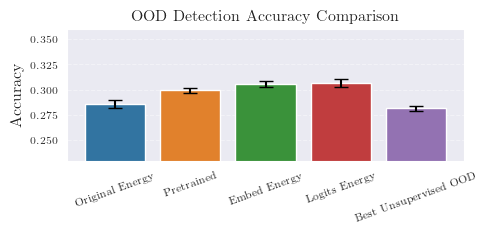

C:\Users\Lindner\AppData\Local\Temp\ipykernel_23724\3296680380.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
C:\Users\Lindner\AppData\Local\Temp\ipykernel_23724\3296680380.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


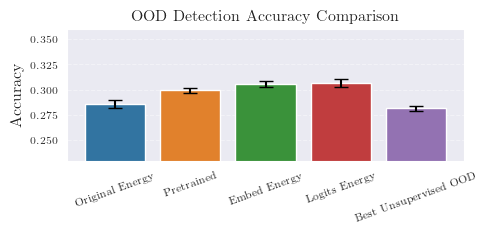

In [35]:
#plot the results
import json
json_orig = savepathname
data_orig = json.load(open(json_orig, "r"))

data_embed = savepath("learned_energy_confidence_later_layer_transformed")
data_embed = json.load(open(data_embed, "r"))

data_logits = savepath("learned_energy_confidence_logits_transformed")
data_logits = json.load(open(data_logits, "r"))

data_embed_pretrained = savepath("learned_energy_confidence_embed_pretrained_transformed")
data_embed_pretrained = json.load(open(data_embed_pretrained, "r"))

data_best = best_score

data_best["accuracy_mean"] = best_score["mean"]
data_best["accuracy_se"] = best_score["se"]

#plot accuracy mean and se
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_accuracy_comparison(datasets, labels, title,save_path=None):
    # Extract scalar means and standard errors
    means = np.array([d['accuracy_mean'] for d in datasets])
    ses   = np.array([d['accuracy_se']   for d in datasets]) *1.96

    x = np.arange(len(labels))

    plt.figure(figsize=(W, W/2))

    # seaborn barplot with tab10 colors
    ax = sns.barplot(
        x=labels,
        y=means,
        palette="tab10",
        ci=None
    )

    # Add SE error bars
    ax.errorbar(
        x=x,
        y=means,
        yerr=ses,
        fmt='none',
        c='black',
        capsize=5
    )

    # Dynamic y-limits
    ymin = (means - ses).min() - 0.05
    ymax = (means + ses).max() + 0.05
    ax.set_ylim(ymin, ymax)

    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    plt.xticks(rotation=20)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()


plot_accuracy_comparison(
    datasets=[data_orig, data_embed_pretrained, data_embed, data_logits, best_score],
    labels=['Original Energy', 'Pretrained', 'Embed Energy', 'Logits Energy', 'Best Unsupervised OOD'],
    title='OOD Detection Accuracy Comparison',
    save_path=os.path.join(figure_path, "accuracy_comparison.pgf")
)
plot_accuracy_comparison(
    datasets=[data_orig, data_embed_pretrained, data_embed, data_logits, best_score],
    labels=['Original Energy', 'Pretrained', 'Embed Energy', 'Logits Energy', 'Best Unsupervised OOD'],
    title='OOD Detection Accuracy Comparison',
    save_path=os.path.join(figure_path, "accuracy_comparison.pdf")
)



In [36]:
stop

NameError: name 'stop' is not defined

In [ ]:
energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)


energy_conf_default = train_or_load_energy_model(
    energy_model2, model_dir_path, namef, train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
}, negative_sampling_module=negative_sampling_module, load_if_exists=True)

In [ ]:
#run the ood detector on the in distribution dataset and track mean score per class
score_sums = np.zeros((n_classes,))
score_counts = np.zeros((n_classes,))
for batch in val_loader:
    inputs, labels = batch
    inputs = inputs.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        scores = energy_conf_default(inputs)[0].squeeze().cpu().numpy()
        #convert logit value to probability via sigmoid
        scores = torch.sigmoid(energy_conf_default(inputs)[0]).squeeze().cpu().numpy()
    labels_np = labels.cpu().numpy()
    for lbl, score in zip(labels_np, scores):
        score_sums[lbl] += score
        score_counts[lbl] += 1

In [ ]:
print("Mean scores per class:")
mean_scores = score_sums / score_counts
for cls in range(n_classes):
    print(f"Class {cls}: {mean_scores[cls]:.4f}")

In [ ]:
dual_output_model = ModelInputOutputWrapper(model, layer, capture_modes=layer_io, flatten=True).to(device)

In [ ]:
import torch
import numpy as np
from typing import Tuple, Optional

def _flatten_embedding_tensor(t: torch.Tensor) -> torch.Tensor:
    # Flatten per-sample embedding to 2D (B, D)
    if t.dim() == 1:
        return t.unsqueeze(0)
    return t.view(t.size(0), -1)

def get_embeddings_simple(dual_model, dataloader, device=torch.device("cuda")) -> Tuple[np.ndarray, np.ndarray]:
    """
    Method A: simply get embeddings for each sample using dual_model.
    Returns (embeddings_t, classes_t) as numpy arrays.
    """
    dual_model.eval()
    embeds_list = []
    labels_list = []
    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = batch[:2]
            inputs = inputs.to(device)
            embeds, _ = dual_model(inputs)  # assume (embeds, logits)
            embeds = _flatten_embedding_tensor(embeds).cpu().numpy()
            embeds_list.append(embeds)
            labels_list.append(labels.cpu().numpy())
    embeddings_t = np.concatenate(embeds_list, axis=0)
    classes_t = np.concatenate(labels_list, axis=0)
    return embeddings_t, classes_t



In [ ]:
torch.randn(2, *dataset_info.input_size).shape

In [ ]:
from confidence.input_transform import RandomProjectionModule

embeddings_s, classes_s = get_embeddings_simple(
    dual_output_model, train_loader_no_shuffle, device=device
)
from confidence.control.split import PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
ip_rp = RandomProjectionModule(n_components=1024)

nn_pytorch_simple = PerClassKNNConfidence(metric="cosine", input_transform=ip_rp)
nn_pytorch_simple.fit(embeddings_s, classes_s)
nn_pytorch_simple.cuda()

conf_split_simple = PredictedSplitConfidence(nn_pytorch_simple, EnergyConfidence(), mult=False, b=0.00)
conf_mod_nn_pytorch_simple = SinglePassConfidence(dual_output_model, conf_split_simple, index=1)
problem_nn_pytorch_simple = TransformationProblem(conf_mod_nn_pytorch_simple, transform_seq,consolidate_method="consolidate_simple",max_batch_size=1280)

#eval
res = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_nn_pytorch_simple,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("nn_pytorch_simple_later_layer_transformed"), show_progress=True,
    repeats=1)
print(res)

In [ ]:
stop

In [ ]:
# python
import torch
import numpy as np
from typing import Optional

# python
import torch
import numpy as np
from typing import Optional

def compute_class_scaling_from_confusion_simple(
    model,
    val_loader,
    n_classes: int,
    device: torch.device = torch.device("cuda"),
    use_confidence: bool = False,
    base_conf_module=None,
) -> torch.Tensor:
    """
    Simplified version: compute per-class scaling from confusion matrix only.

    Scale per predicted class j:
      raw_j = (true_positive_j) / (predicted_as_j)

    This is simply the precision per class. Normalize to mean 1 and clamp.
    """
    model.eval()

    conf_mat = np.zeros((n_classes, n_classes), dtype=np.int64)

    with torch.no_grad():
        for batch in val_loader:
            inputs, labels = batch[:2]
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            preds = logits.argmax(dim=-1)

            labels_np = labels.detach().cpu().numpy()
            preds_np = preds.detach().cpu().numpy()

            for t, p in zip(labels_np, preds_np):
                conf_mat[t, p] += 1

    # Per-class precision (TP / total predicted)
    preds_per_class = conf_mat.sum(axis=0)
    true_positive = np.diag(conf_mat)

    precision = true_positive / np.maximum(1, preds_per_class)
    # Handle never-predicted classes
    precision = np.where(preds_per_class == 0, 1.0, precision)

    # Normalize to mean 1
    mean_prec = max(np.mean(precision), 1e-6)
    normalized = precision / mean_prec
    clipped = np.clip(normalized, 0.5, 2.0)

    return torch.tensor(clipped, dtype=torch.float32, device=device)




scaling_factors = compute_class_scaling_from_confusion_simple(
    base_conf_module=energy_conf_default,
    model=model,
    val_loader=val_loader,
    n_classes=n_classes,
    device=device,
    use_confidence=False,

)
# python
import torch
from typing import Optional, Tuple
import tqdm

@torch.no_grad()
def compute_confusion_matrix_over_loader(
    model,
    optimizer,
    problem,
    loader,
    device: torch.device,
    num_classes: int,
    ignore_label_neg: bool = True,
    normalize: bool = False,
) -> torch.Tensor:
    """
    Compute confusion matrix by running optimizer + model over a loader.

    Returns:
        confusion_matrix: tensor of shape [num_classes, num_classes]
    """
    model.eval()
    if problem.confidence_module is not None:
        problem.confidence_module.eval()

    # Prepare problem for ITSWRAPPER if needed
    if isinstance(optimizer, ITSWRAPPER):
        problem = ITSWRAPPER._prepare_problem(problem)

    confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64, device=device)

    for data, target in tqdm.tqdm(loader, desc="Computing Confusion Matrix"):
        data = data.to(device)
        target = target.to(device)

        # Filter out negative labels if requested
        if ignore_label_neg:
            mask = target >= 0
            if not mask.any():
                continue
            data = data[mask]
            target = target[mask]

        # Optimize to get transformed data
        if isinstance(optimizer, ITSWRAPPER):
            # ITSWRAPPER returns (best_matrix, best_error, logits, data_canonic)
            _, _, _, x_trans = optimizer.optimize(problem, data)
        else:
            # Standard optimizer returns (best_param, best_error, best_classes)
            result = optimizer.optimize(problem, data, y=None)
            if isinstance(result, tuple) and len(result) >= 1:
                best_param = result[0]
            else:
                best_param = result
            x_trans = problem.transform(data, best_param)

        # Forward pass
        logits = model(x_trans)
        if logits.dim() < 2:
            raise ValueError("Model logits must have shape [batch, num_classes].")

        preds = logits.argmax(dim=-1)

        # Update confusion matrix
        for t, p in zip(target, preds):
            confusion[t.long(), p.long()] += 1

    # Normalize if requested
    if normalize:
        row_sums = confusion.sum(dim=1, keepdim=True)
        confusion = confusion.float() / (row_sums + 1e-10)

    return confusion


from confidence.control.split import PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
ip_rp = RandomProjectionModule(n_components=1024)

nn_pytorch_simple = PerClassKNNConfidence(metric="cosine", input_transform=ip_rp)
nn_pytorch_simple.fit(embeddings_s, classes_s)
nn_pytorch_simple.cuda()

import torch
import torch.nn as nn

class ClassBasedScalingConfidence(nn.Module):
    def __init__(self, base_confidence_module, class_mean_scores):
        super().__init__()
        self.base_confidence_module = base_confidence_module
        self.class_mean_scores = class_mean_scores**0.1

    def forward(self, x, y_pred):
        base_conf = self.base_confidence_module(x,y_pred)  # base_conf: (B,) or (B,1)

        # Vectorized scaling lookup
        scaling_factors = self.class_mean_scores[y_pred]  # (B,)

        scaled_conf = base_conf * scaling_factors  # elementwise
        return scaled_conf



conf_split_simple = PredictedSplitConfidence(nn_pytorch_simple, EnergyConfidence(), mult=False, b=0.00)
conf_mod_nn_pytorch_simple = SinglePassConfidence(dual_output_model, conf_split_simple, index=1)
problem_nn_pytorch_simple = TransformationProblem(conf_mod_nn_pytorch_simple, transform_seq,consolidate_method="consolidate_simple",max_batch_size=1280)


print("Computing scaling factors from confusion matrix...")
scaling_factors = compute_confusion_matrix_over_loader(
    model=model,
    optimizer=optimizer,
    problem=problem_nn_pytorch_simple,
    loader=val_loader,
    device=device,
    num_classes=n_classes,
    ignore_label_neg=True,
    normalize=True,
).diag()

In [ ]:
scaling_factors

In [ ]:
from confidence.control.split import PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
ip_rp = RandomProjectionModule(n_components=1024)

nn_pytorch_simple = PerClassKNNConfidence(metric="cosine", input_transform=ip_rp)
nn_pytorch_simple.fit(embeddings_s, classes_s)
nn_pytorch_simple.cuda()

import torch
import torch.nn as nn

class ClassBasedScalingConfidence(nn.Module):
    def __init__(self, base_confidence_module, class_mean_scores):
        super().__init__()
        self.base_confidence_module = base_confidence_module
        self.class_mean_scores = class_mean_scores**0.1

    def forward(self, x, y_pred):
        base_conf = self.base_confidence_module(x,y_pred)  # base_conf: (B,) or (B,1)

        # Vectorized scaling lookup
        scaling_factors = self.class_mean_scores[y_pred]  # (B,)

        scaled_conf = base_conf * scaling_factors  # elementwise
        return scaled_conf

nn_pytorch_simple = ClassBasedScalingConfidence(nn_pytorch_simple, torch.tensor(scaling_factors).to(device))




conf_split_simple = PredictedSplitConfidence(nn_pytorch_simple, EnergyConfidence(), mult=False, b=0.00)
conf_mod_nn_pytorch_simple = SinglePassConfidence(dual_output_model, conf_split_simple, index=1)
problem_nn_pytorch_simple = TransformationProblem(conf_mod_nn_pytorch_simple, transform_seq,consolidate_method="consolidate_simple",max_batch_size=1280)

#eval
res = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_nn_pytorch_simple,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("nn_pytorch_simple_later_layer_transformed_scaled5"), show_progress=True,
    repeats=1)
print(res)

In [ ]:
stop

In [ ]:
import torch
import numpy as np
from typing import Tuple, Optional
@torch.no_grad()
def get_embeddings_by_max_transformed_proba(
    dual_model,
    base_model,
    dataloader,
    transform_seq,
    n_transforms: int = 8,
    device: torch.device = torch.device("cuda"),
    chunk_size: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray]:

    dual_model.eval()
    base_model.eval()

    embeds_list = []
    labels_list = []

    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = batch[:2]
            B = inputs.size(0)
            inputs = inputs.to(device)
            labels = labels.to(device)

            # --- 1) Generate transform parameters (B, n_transforms, param_dim)
            params = transform_seq.initial_param(batch_size=B, n_samples=n_transforms)
            if not isinstance(params, torch.Tensor):
                params = torch.tensor(params, device=device)
            params = params.to(device)

            # Flatten for transform call (B*n_transforms, param_dim)
            params_flat = params.view(B * n_transforms, -1)

            # Repeat inputs for transforms
            inputs_rep = inputs.repeat_interleave(n_transforms, dim=0)

            # --- 2) Append original inputs as an extra "transform index 0" ---
            # We do this by concatenating:
            # transformed_inputs = [inputs (original), transform(inputs), transform(inputs), ...]
            total_transformed = B * n_transforms
            total = total_transformed + B  # +B for originals

            # containers
            probs_all = []
            embeds_all = []

            # --- Process originals first ---
            logits_orig = base_model(inputs)
            probs_orig = torch.softmax(logits_orig, dim=-1)
            embeds_orig, _ = dual_model(inputs)
            embeds_orig = _flatten_embedding_tensor(embeds_orig)
            probs_all.append(probs_orig)
            embeds_all.append(embeds_orig)

            # --- Process transformed inputs (chunked if needed) ---
            if chunk_size is None or chunk_size >= total_transformed:
                transformed = transform_seq.transform(inputs_rep, params_flat)
                logits = base_model(transformed)
                probs = torch.softmax(logits, dim=-1)
                embeds, _ = dual_model(transformed)
                embeds = _flatten_embedding_tensor(embeds)
                probs_all.append(probs)
                embeds_all.append(embeds)
            else:
                # chunked pass
                for start in range(0, total_transformed, chunk_size):
                    end = min(start + chunk_size, total_transformed)
                    t_chunk = transform_seq.transform(inputs_rep[start:end], params_flat[start:end])
                    logits = base_model(t_chunk)
                    probs = torch.softmax(logits, dim=-1)
                    embeds, _ = dual_model(t_chunk)
                    embeds = _flatten_embedding_tensor(embeds)
                    probs_all.append(probs)
                    embeds_all.append(embeds)

            # Concatenate for shape: ( (1 + n_transforms)*B, num_classes ) and (same for embeddings)
            probs_flat = torch.cat(probs_all, dim=0)
            embeds_flat = torch.cat(embeds_all, dim=0)

            # Reshape to (B, 1 + n_transforms, ...)
            n_total = n_transforms + 1
            probs_reshaped = probs_flat.view(B, n_total, -1)
            embeds_reshaped = embeds_flat.view(B, n_total, -1)

            # True-class prob
            true_probs = probs_reshaped.gather(
                2, labels.view(B, 1, 1).expand(-1, n_total, 1)
            ).squeeze(-1)

            # Best competitor prob (mask out true class)
            probs_others = probs_reshaped.clone()
            probs_others.scatter_(
                2,
                labels.view(B, 1, 1).expand(-1, n_total, 1),
                -float("inf")
            )
            best_others = probs_others.max(dim=2).values

            # Margin = p(true) - p(best other)
            margins = true_probs - best_others

            # Select index maximizing margin
            best_idx = margins.argmax(dim=1)

            # Final selected embeddings
            selected_embeds = embeds_reshaped[torch.arange(B, device=device), best_idx, :]

            embeds_list.append(selected_embeds.cpu().numpy())
            labels_list.append(labels.cpu().numpy())

    embeddings_t = np.concatenate(embeds_list, axis=0)
    classes_t = np.concatenate(labels_list, axis=0)
    return embeddings_t, classes_t


In [ ]:
embeddings_t, classes_t = get_embeddings_by_max_transformed_proba(
    dual_output_model, model, train_loader_no_shuffle, transform_seq, n_transforms=12, device=device
)
from confidence.control.split import PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=ip_rp)

nn_pytorch_pretrained.fit(torch.tensor(embeddings_t,device=device), torch.tensor(classes_t,device=device))
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.00)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
conf_mod_nn_pytorch_pretrained.to(device)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple",max_batch_size=1280)




In [ ]:
res = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("nn_pytorch_pretrained_later_layer_transformed"), show_progress=True,
    repeats=1)
print(res)

In [ ]:
import torch
import numpy as np
from typing import Tuple, Optional

def _flatten_embedding_tensor(t: torch.Tensor) -> torch.Tensor:
    # Flatten per-sample embedding to 2D (B, D)
    if t.dim() == 1:
        return t.unsqueeze(0)
    return t.view(t.size(0), -1)
@torch.no_grad()
def get_embeddings_best_2x_with_originals(
    dual_model,
    base_model,
    dataloader,
    transform_seq,
    n_transforms: int = 8,
    device: torch.device = torch.device("cuda"),
    chunk_size: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Select 2×B samples total:
    - B originals (always included)
    - B best transformed samples (selected globally by margin across all B×n_transforms options)

    Returns (embeddings_t, classes_t) as numpy arrays with shape (2*total_samples, ...).
    """
    dual_model.eval()
    base_model.eval()

    embeds_list = []
    labels_list = []

    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = batch[:2]
            B = inputs.size(0)
            inputs = inputs.to(device)
            labels = labels.to(device)

            # --- 1) Generate transform parameters (B, n_transforms, param_dim)
            params = transform_seq.initial_param(batch_size=B, n_samples=n_transforms)
            if not isinstance(params, torch.Tensor):
                params = torch.tensor(params, device=device)
            params = params.to(device)

            # Flatten for transform call (B*n_transforms, param_dim)
            params_flat = params.view(B * n_transforms, -1)

            # Repeat inputs for transforms
            inputs_rep = inputs.repeat_interleave(n_transforms, dim=0)

            # --- 2) Process original inputs ---
            logits_orig = base_model(inputs)
            probs_orig = torch.softmax(logits_orig, dim=-1)
            embeds_orig, _ = dual_model(inputs)
            embeds_orig = _flatten_embedding_tensor(embeds_orig)

            # --- 3) Process transformed inputs (chunked if needed) ---
            total_transformed = B * n_transforms

            probs_transformed_list = []
            embeds_transformed_list = []

            if chunk_size is None or chunk_size >= total_transformed:
                transformed = transform_seq.transform(inputs_rep, params_flat)
                logits = base_model(transformed)
                probs = torch.softmax(logits, dim=-1)
                embeds, _ = dual_model(transformed)
                embeds = _flatten_embedding_tensor(embeds)
                probs_transformed_list.append(probs)
                embeds_transformed_list.append(embeds)
            else:
                # chunked pass
                for start in range(0, total_transformed, chunk_size):
                    end = min(start + chunk_size, total_transformed)
                    t_chunk = transform_seq.transform(inputs_rep[start:end], params_flat[start:end])
                    logits = base_model(t_chunk)
                    probs = torch.softmax(logits, dim=-1)
                    embeds, _ = dual_model(t_chunk)
                    embeds = _flatten_embedding_tensor(embeds)
                    probs_transformed_list.append(probs)
                    embeds_transformed_list.append(embeds)

            # Concatenate transformed results: (B*n_transforms, num_classes) and (B*n_transforms, D)
            probs_transformed = torch.cat(probs_transformed_list, dim=0)
            embeds_transformed = torch.cat(embeds_transformed_list, dim=0)

            # --- 4) Compute margins for transformed samples ---
            # We need to match each transformed sample to its original label
            # labels_rep: (B*n_transforms,) where each label is repeated n_transforms times
            labels_rep = labels.repeat_interleave(n_transforms)

            num_classes = probs_transformed.size(-1)

            # True-class probabilities for transformed samples
            true_probs_transformed = probs_transformed.gather(
                1, labels_rep.view(-1, 1)
            ).squeeze(-1)  # (B*n_transforms,)

            # Best competitor probability (mask out true class)
            probs_others = probs_transformed.clone()
            probs_others.scatter_(1, labels_rep.view(-1, 1), -float("inf"))
            best_others_transformed = probs_others.max(dim=1).values  # (B*n_transforms,)

            # Margin = p(true) - p(best other)
            margins_transformed = true_probs_transformed - best_others_transformed  # (B*n_transforms,)

            # --- 5) Select top-B transformed samples globally based on margin ---
            top_B_margins, top_B_idx = margins_transformed.topk(B)  # Select B best from all B*n_transforms

            # Get the selected embeddings and labels
            selected_transformed_embeds = embeds_transformed[top_B_idx]  # (B, D)
            selected_transformed_labels = labels_rep[top_B_idx]  # (B,)

            # --- 6) Combine originals + selected transformed ---
            # Result: 2*B samples (B originals + B best transformed)
            combined_embeds = torch.cat([embeds_orig, selected_transformed_embeds], dim=0)  # (2*B, D)
            combined_labels = torch.cat([labels, selected_transformed_labels], dim=0)  # (2*B,)

            embeds_list.append(combined_embeds.cpu().numpy())
            labels_list.append(combined_labels.cpu().numpy())

    embeddings_t = np.concatenate(embeds_list, axis=0)
    classes_t = np.concatenate(labels_list, axis=0)
    return embeddings_t, classes_t

In [ ]:
embeddings_t, classes_t = get_embeddings_best_2x_with_originals(
    dual_output_model, model, train_loader_no_shuffle, transform_seq, n_transforms=24, device=device
)
from confidence.control.split import PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
nn_pytorch_best2x = PerClassKNNConfidence(metric="cosine", input_transform=ip_rp)
nn_pytorch_best2x.fit(torch.tensor(embeddings_t,device=device), torch.tensor(classes_t,device=device))
nn_pytorch_best2x.cuda()
conf_split_best2x = PredictedSplitConfidence(nn_pytorch_best2x, EnergyConfidence(), mult=False, b=0.00)
conf_mod_nn_pytorch_best2x = SinglePassConfidence(dual_output_model, conf_split_best2x, index=1)
conf_mod_nn_pytorch_best2x.to(device)
problem_nn_pytorch_best2x = TransformationProblem(conf_mod_nn_pytorch_best2x, transform_seq,
                                                  consolidate_method="consolidate_simple",max_batch_size=1280)

In [ ]:
res = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_nn_pytorch_best2x,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("nn_pytorch_best2x_later_layer_transformed"), show_progress=True,
    repeats=1)
print(res)